In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the cleaned dataset

file_path = r"D:\document\AFTER_GRADUATION\DATAANALYSE\MINE\PROJECT4HEALTHCARE\data\cleaned\diabetes_cleaned_final.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (379170, 21)


,GENHLTH,PHYSHLTH,MENTHLTH,BLOODCHO,CHOLCHK,CVDINFR4,CVDCRHD4,CVDSTRK3,SEX,EDUCA,...,DIFFWALK,SMOKE100,EXERANY2,_AGEG5YR,Diabetes_binary,BMI,Alcohol_days_per_month,Fruit_juice_per_day,Fruit_per_day,Vegetables_per_day
0,5.0,15.0,18.0,1.0,1.0,2.0,2.0,2.0,2.0,4.0,...,1.0,1.0,2.0,9.0,0,40.18,0.0,0.166667,0.333333,1.000000
1,3.0,0.0,0.0,1.0,4.0,2.0,2.0,2.0,2.0,6.0,...,2.0,1.0,1.0,7.0,0,25.09,0.0,0.066667,0.166667,0.133333
2,5.0,30.0,30.0,1.0,1.0,2.0,2.0,2.0,2.0,4.0,...,1.0,2.0,2.0,9.0,0,28.19,0.0,0.000000,1.000000,0.142857
3,5.0,20.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,5.0,...,2.0,2.0,2.0,9.0,0,24.37,0.0,0.100000,2.000000,0.666667
4,2.0,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,3.0,...,2.0,2.0,1.0,11.0,0,26.52,0.0,1.000000,1.000000,1.000000


In [3]:
# Display basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379170 entries, 0 to 379169
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   GENHLTH                 379170 non-null  float64
 1   PHYSHLTH                379170 non-null  float64
 2   MENTHLTH                379170 non-null  float64
 3   BLOODCHO                379170 non-null  float64
 4   CHOLCHK                 379170 non-null  float64
 5   CVDINFR4                379170 non-null  float64
 6   CVDCRHD4                379170 non-null  float64
 7   CVDSTRK3                379170 non-null  float64
 8   SEX                     379170 non-null  float64
 9   EDUCA                   379170 non-null  float64
 10  INCOME2                 379170 non-null  float64
 11  DIFFWALK                379170 non-null  float64
 12  SMOKE100                379170 non-null  float64
 13  EXERANY2                379170 non-null  float64
 14  _AGEG5YR            

In [4]:
# Check column names

df.columns

Index(['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'BLOODCHO', 'CHOLCHK', 'CVDINFR4',
       'CVDCRHD4', 'CVDSTRK3', 'SEX', 'EDUCA', 'INCOME2', 'DIFFWALK',
       'SMOKE100', 'EXERANY2', '_AGEG5YR', 'Diabetes_binary', 'BMI',
       'Alcohol_days_per_month', 'Fruit_juice_per_day', 'Fruit_per_day',
       'Vegetables_per_day'],
      dtype='object')

In [5]:
# Check missing values

df.isnull().sum().sort_values(ascending=False)

GENHLTH                   0
DIFFWALK                  0
Fruit_per_day             0
Fruit_juice_per_day       0
Alcohol_days_per_month    0
BMI                       0
Diabetes_binary           0
_AGEG5YR                  0
EXERANY2                  0
SMOKE100                  0
INCOME2                   0
PHYSHLTH                  0
EDUCA                     0
SEX                       0
CVDSTRK3                  0
CVDCRHD4                  0
CVDINFR4                  0
CHOLCHK                   0
BLOODCHO                  0
MENTHLTH                  0
Vegetables_per_day        0
dtype: int64

In [6]:
# Check duplicated rows

df.duplicated().sum()

137

In [7]:
# Check diabetes target distribution

diabetes_counts = df["Diabetes_binary"].value_counts().sort_index()
diabetes_percent = df["Diabetes_binary"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "Count": diabetes_counts,
    "Percentage": diabetes_percent.round(2)
})

target_distribution.index = ["No diabetes", "Diabetes"]

target_distribution

,Count,Percentage
No diabetes,329471,86.89
Diabetes,49699,13.11


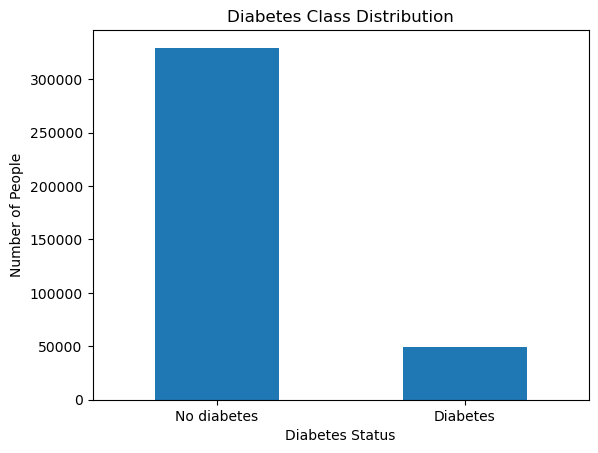

In [8]:
# Visualize diabetes target distribution

target_distribution["Count"].plot(kind="bar")

plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of People")
plt.xticks(rotation=0)
plt.show()

In [9]:
# Select numerical features

numeric_features = [
    "BMI",
    "PHYSHLTH",
    "MENTHLTH",
    "Alcohol_days_per_month",
    "Fruit_juice_per_day",
    "Fruit_per_day",
    "Vegetables_per_day"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,379170.0,27.970179,6.422628,12.02,24.030000,26.950000,30.540000,97.65
PHYSHLTH,379170.0,4.148195,8.655975,0.00,0.000000,0.000000,3.000000,30.00
MENTHLTH,379170.0,3.229549,7.495147,0.00,0.000000,0.000000,2.000000,30.00
Alcohol_days_per_month,379170.0,4.776401,8.090278,0.00,0.000000,1.000000,5.000000,30.00
Fruit_juice_per_day,379170.0,0.341865,0.663247,0.00,0.000000,0.100000,0.428571,99.00
Fruit_per_day,379170.0,1.009038,1.044194,0.00,0.428571,1.000000,1.000000,99.00
Vegetables_per_day,379170.0,0.802540,0.767807,0.00,0.428571,0.714286,1.000000,99.00


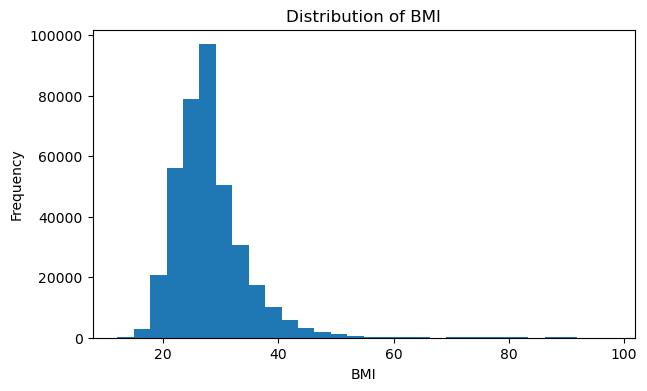

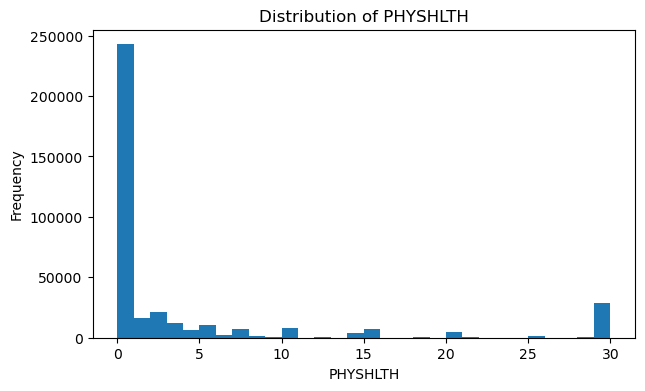

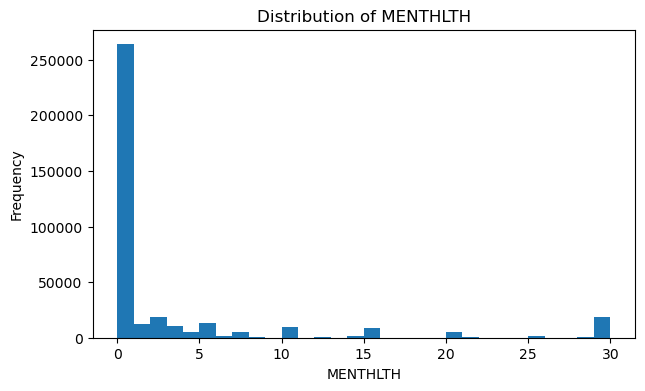

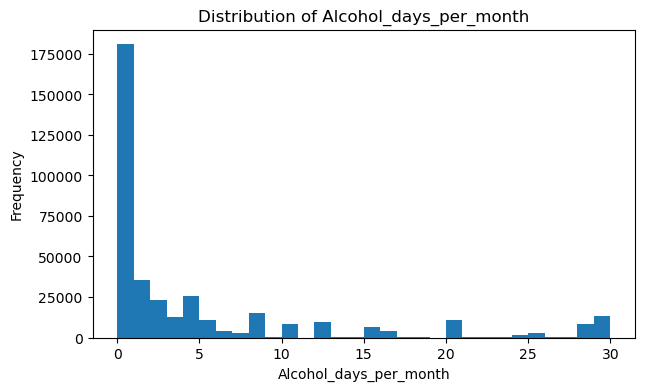

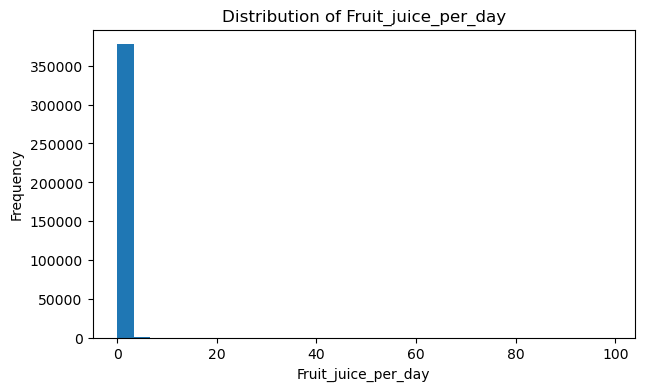

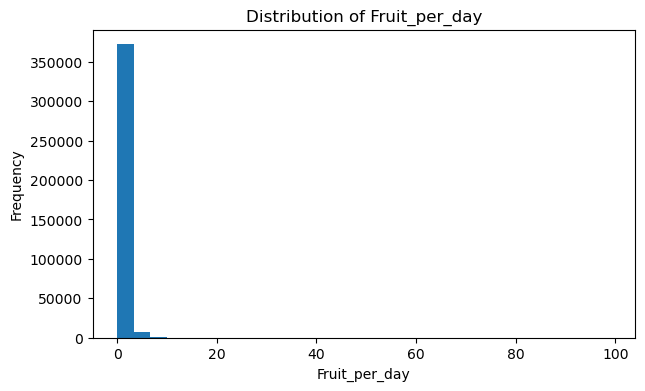

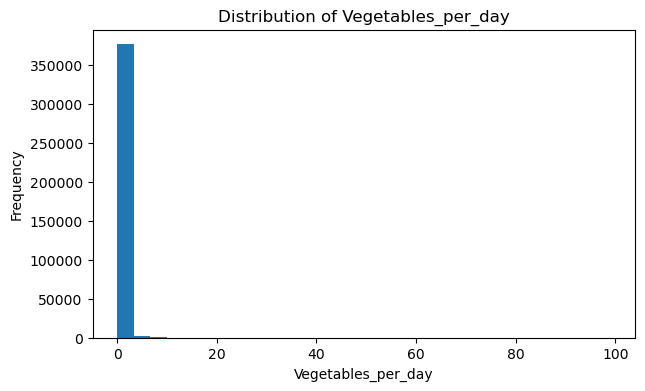

In [10]:
# Plot histograms for numerical features

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

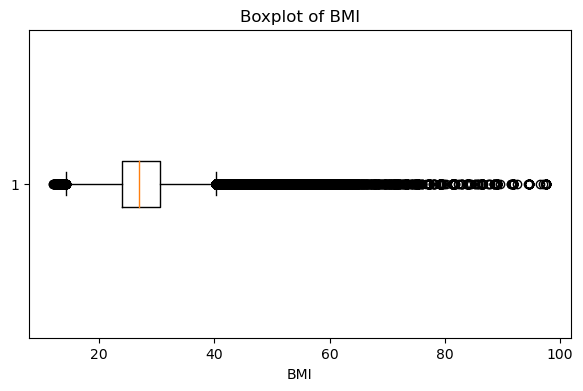

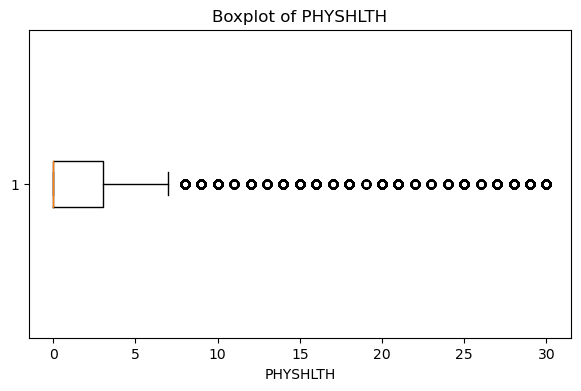

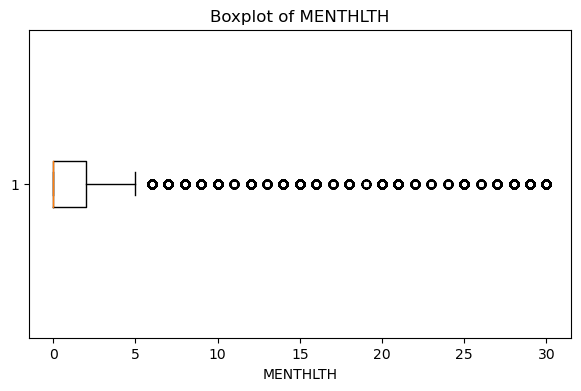

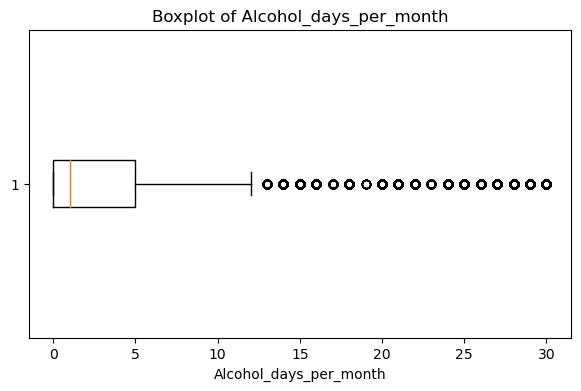

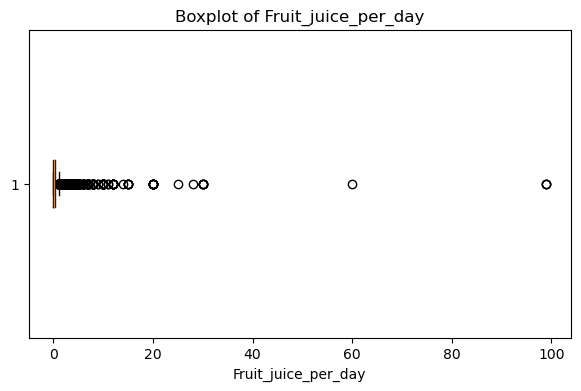

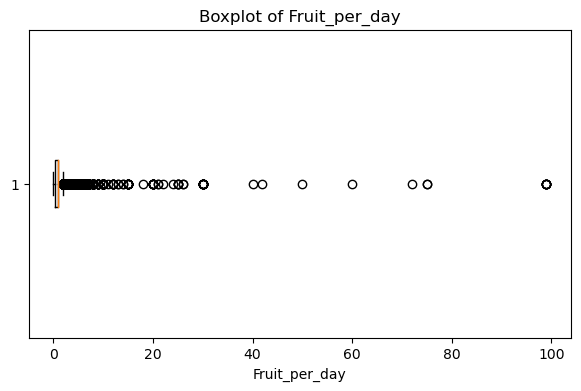

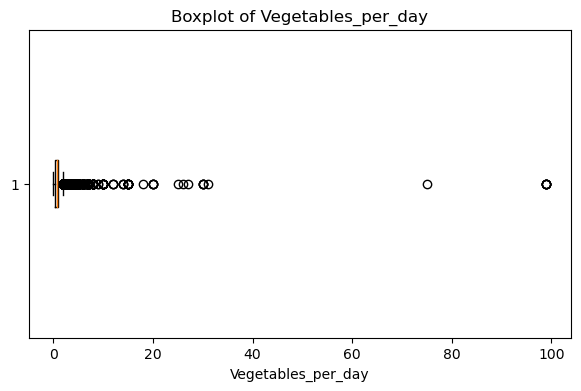

In [11]:
# Plot boxplots for numerical features to check extreme values

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [12]:
# Select categorical and coded features

categorical_features = [
    "GENHLTH",
    "BLOODCHO",
    "CHOLCHK",
    "CVDINFR4",
    "CVDCRHD4",
    "CVDSTRK3",
    "SEX",
    "EDUCA",
    "INCOME2",
    "DIFFWALK",
    "SMOKE100",
    "EXERANY2",
    "_AGEG5YR"
]

for col in categorical_features:
    print("\nColumn:", col)
    print(df[col].value_counts().sort_index())


Column: GENHLTH
GENHLTH
1.0     68082
2.0    129288
3.0    116208
4.0     47307
5.0     18285
Name: count, dtype: int64

Column: BLOODCHO
BLOODCHO
1.0    335443
2.0     43727
Name: count, dtype: int64

Column: CHOLCHK
CHOLCHK
1.0    256118
2.0     39212
3.0     71652
4.0     12188
Name: count, dtype: int64

Column: CVDINFR4
CVDINFR4
1.0     20608
2.0    358562
Name: count, dtype: int64

Column: CVDCRHD4
CVDCRHD4
1.0     21513
2.0    357657
Name: count, dtype: int64

Column: CVDSTRK3
CVDSTRK3
1.0     14686
2.0    364484
Name: count, dtype: int64

Column: SEX
SEX
1.0    162587
2.0    216583
Name: count, dtype: int64

Column: EDUCA
EDUCA
1.0       463
2.0      8408
3.0     17860
4.0    103773
5.0    104500
6.0    144166
Name: count, dtype: int64

Column: INCOME2
INCOME2
1.0     14948
2.0     16151
3.0     22635
4.0     27808
5.0     34251
6.0     46549
7.0     52977
8.0    106513
9.0     57338
Name: count, dtype: int64

Column: DIFFWALK
DIFFWALK
1.0     62130
2.0    317040
Name: count, d

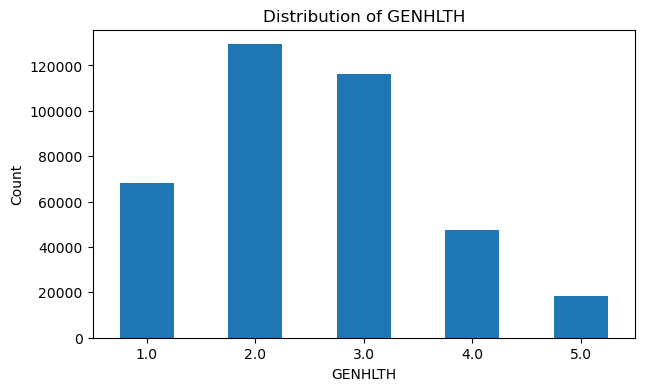

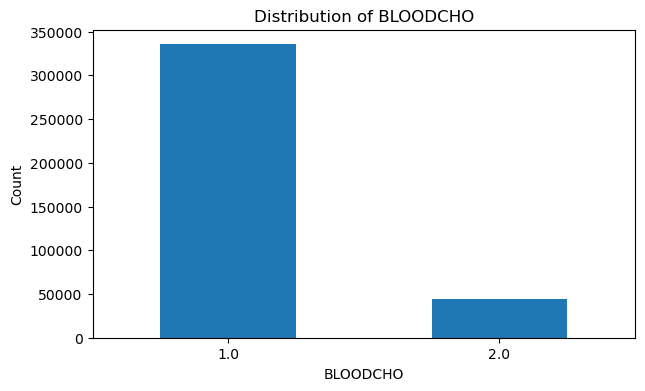

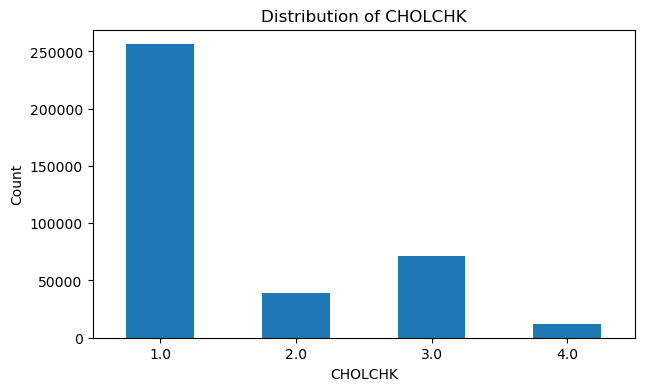

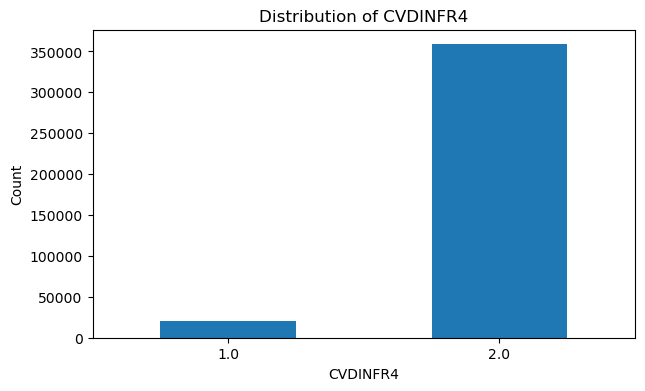

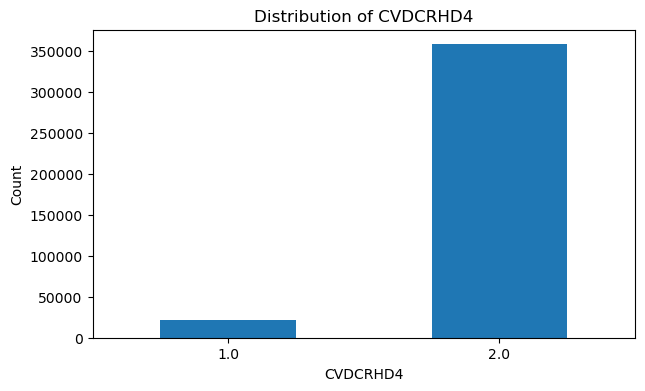

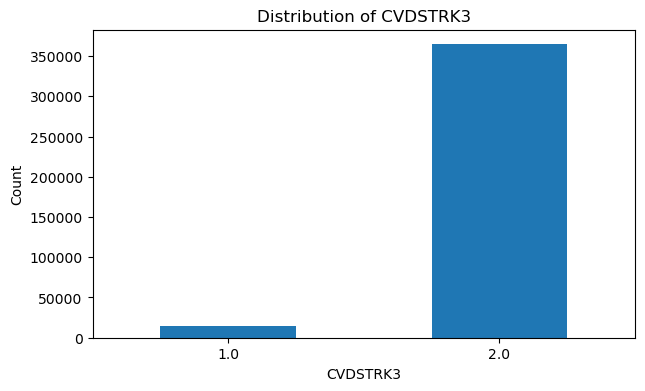

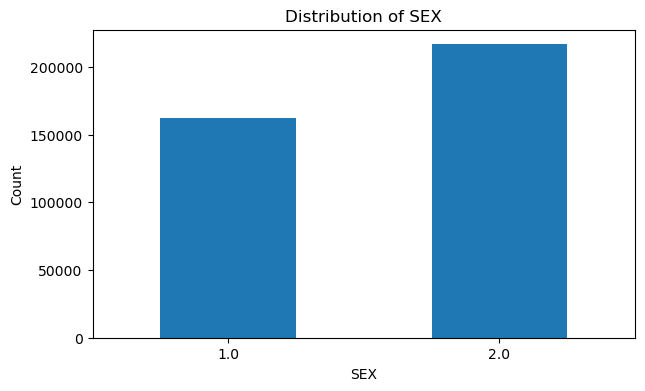

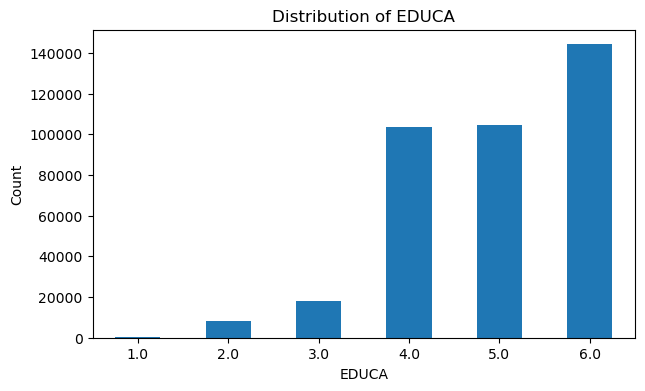

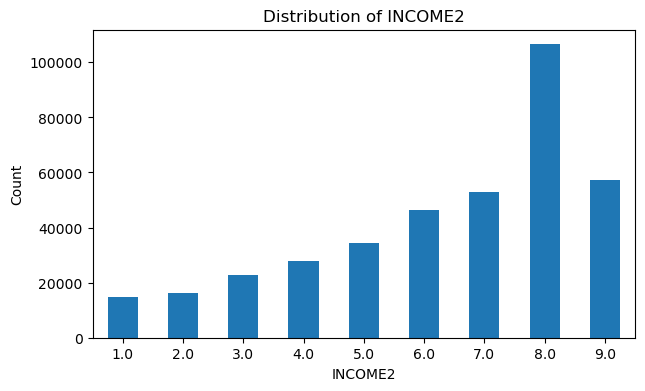

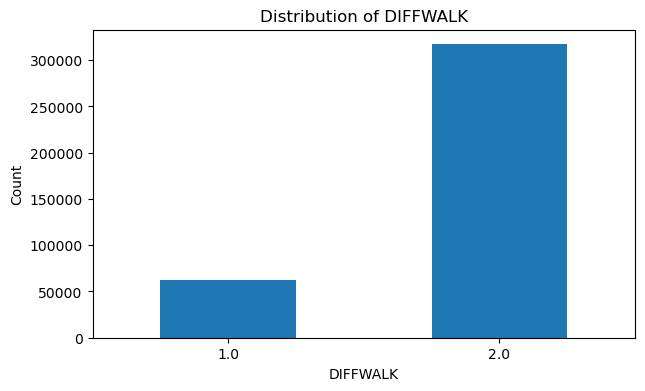

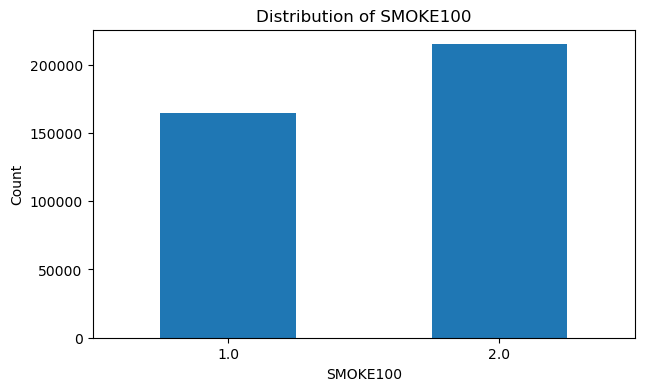

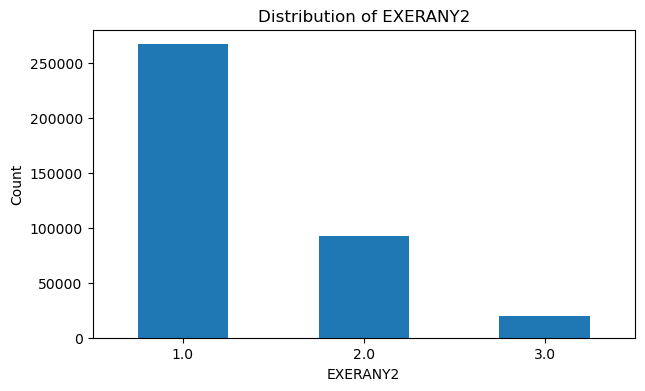

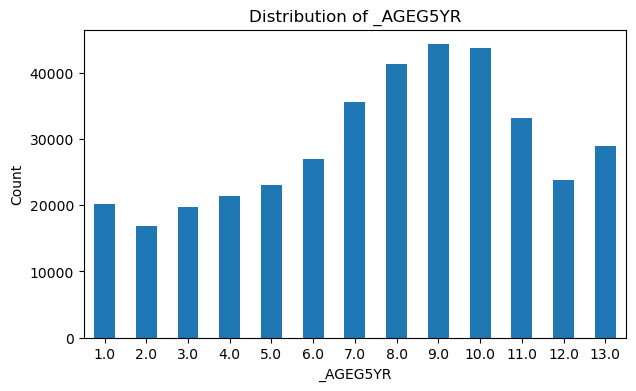

In [13]:
# Visualize categorical feature distributions

for col in categorical_features:
    plt.figure(figsize=(7, 4))
    df[col].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [14]:
# This function calculates diabetes rate for each category of a feature

def diabetes_rate_by_group(data, feature):
    result = data.groupby(feature)["Diabetes_binary"].agg(
        Total="count",
        Diabetes_cases="sum",
        Diabetes_rate="mean"
    ).reset_index()
    
    result["Diabetes_rate"] = (result["Diabetes_rate"] * 100).round(2)
    
    return result

In [15]:
# Diabetes rate by age group

age_diabetes_rate = diabetes_rate_by_group(df, "_AGEG5YR")
age_diabetes_rate

,_AGEG5YR,Total,Diabetes_cases,Diabetes_rate
0,1.0,20209,194,0.96
1,2.0,16893,249,1.47
2,3.0,19788,463,2.34
3,4.0,21458,892,4.16
4,5.0,23063,1447,6.27
5,6.0,27022,2321,8.59
6,7.0,35617,4052,11.38
7,8.0,41325,5663,13.70
8,9.0,44279,7682,17.35
9,10.0,43695,8930,20.44


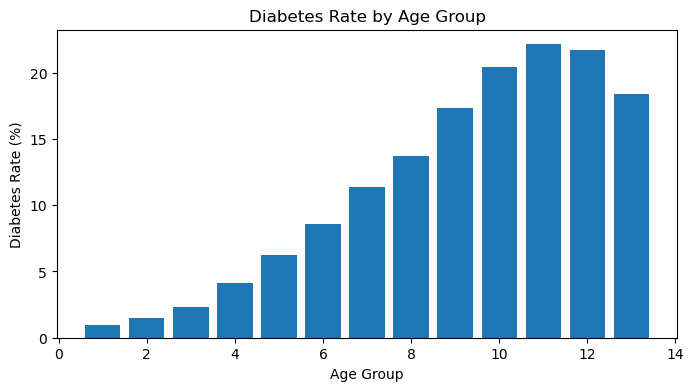

In [16]:
# Visualize diabetes rate by age group

plt.figure(figsize=(8, 4))
plt.bar(age_diabetes_rate["_AGEG5YR"], age_diabetes_rate["Diabetes_rate"])
plt.title("Diabetes Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Rate (%)")
plt.show()

In [17]:
# Create BMI categories

df["BMI_category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

bmi_diabetes_rate = diabetes_rate_by_group(df, "BMI_category")
bmi_diabetes_rate

,BMI_category,Total,Diabetes_cases,Diabetes_rate
0,Underweight,5631,257,4.56
1,Normal,116228,6501,5.59
2,Overweight,152410,18003,11.81
3,Obese,104901,24938,23.77


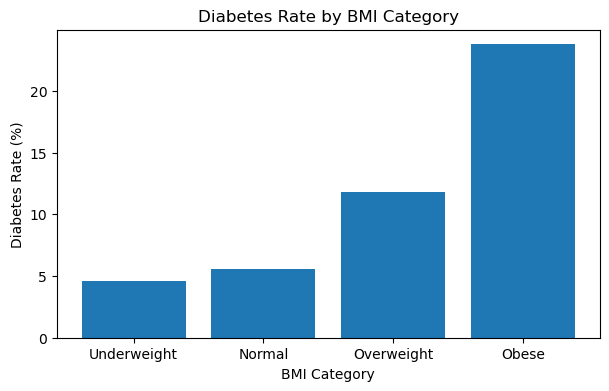

In [18]:
# Visualize diabetes rate by BMI category

plt.figure(figsize=(7, 4))
plt.bar(bmi_diabetes_rate["BMI_category"].astype(str), bmi_diabetes_rate["Diabetes_rate"])
plt.title("Diabetes Rate by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [19]:
# Diabetes rate by general health

genhlth_diabetes_rate = diabetes_rate_by_group(df, "GENHLTH")
genhlth_diabetes_rate

,GENHLTH,Total,Diabetes_cases,Diabetes_rate
0,1.0,68082,1624,2.39
1,2.0,129288,8632,6.68
2,3.0,116208,18777,16.16
3,4.0,47307,13854,29.29
4,5.0,18285,6812,37.25


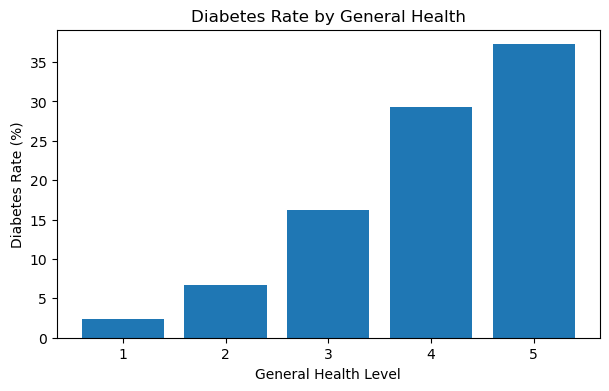

In [20]:
# Visualize diabetes rate by general health

plt.figure(figsize=(7, 4))
plt.bar(genhlth_diabetes_rate["GENHLTH"], genhlth_diabetes_rate["Diabetes_rate"])
plt.title("Diabetes Rate by General Health")
plt.xlabel("General Health Level")
plt.ylabel("Diabetes Rate (%)")
plt.show()

In [21]:
# Diabetes rate by physical activity

exercise_diabetes_rate = diabetes_rate_by_group(df, "EXERANY2")
exercise_diabetes_rate

,EXERANY2,Total,Diabetes_cases,Diabetes_rate
0,1.0,266987,29068,10.89
1,2.0,92788,18250,19.67
2,3.0,19395,2381,12.28


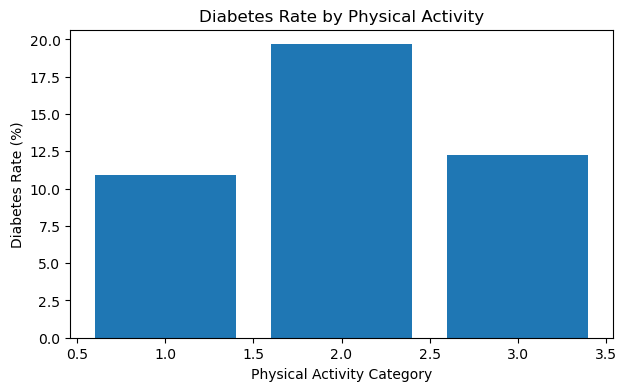

In [22]:
# Visualize diabetes rate by physical activity

plt.figure(figsize=(7, 4))
plt.bar(exercise_diabetes_rate["EXERANY2"], exercise_diabetes_rate["Diabetes_rate"])
plt.title("Diabetes Rate by Physical Activity")
plt.xlabel("Physical Activity Category")
plt.ylabel("Diabetes Rate (%)")
plt.show()

In [23]:
# Diabetes rate by income group

income_diabetes_rate = diabetes_rate_by_group(df, "INCOME2")
income_diabetes_rate

,INCOME2,Total,Diabetes_cases,Diabetes_rate
0,1.0,14948,3115,20.84
1,2.0,16151,3783,23.42
2,3.0,22635,4397,19.43
3,4.0,27808,4959,17.83
4,5.0,34251,5332,15.57
5,6.0,46549,6189,13.30
6,7.0,52977,6037,11.40
7,8.0,106513,8065,7.57
8,9.0,57338,7822,13.64


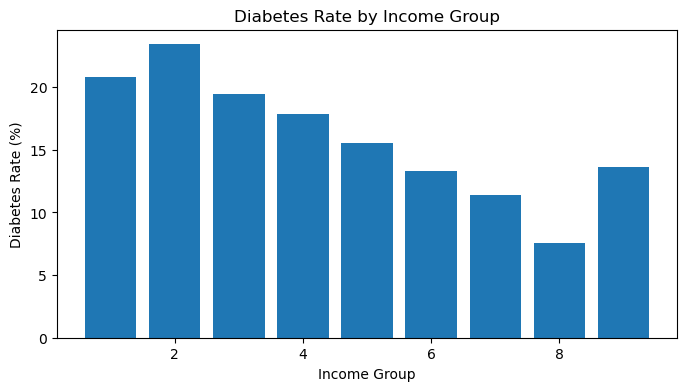

In [24]:
# Visualize diabetes rate by income group

plt.figure(figsize=(8, 4))
plt.bar(income_diabetes_rate["INCOME2"], income_diabetes_rate["Diabetes_rate"])
plt.title("Diabetes Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Diabetes Rate (%)")
plt.show()

In [25]:
# Diabetes rate by heart disease or heart attack

heart_diabetes_rate = diabetes_rate_by_group(df, "CVDINFR4")
heart_diabetes_rate

,CVDINFR4,Total,Diabetes_cases,Diabetes_rate
0,1.0,20608,7180,34.84
1,2.0,358562,42519,11.86


In [26]:
# Diabetes rate by stroke

stroke_diabetes_rate = diabetes_rate_by_group(df, "CVDSTRK3")
stroke_diabetes_rate

,CVDSTRK3,Total,Diabetes_cases,Diabetes_rate
0,1.0,14686,4661,31.74
1,2.0,364484,45038,12.36


In [27]:
# Calculate correlation with the diabetes target

correlation_with_diabetes = df.corr(numeric_only=True)["Diabetes_binary"].sort_values(ascending=False)

correlation_with_diabetes

Diabetes_binary           1.000000
GENHLTH                   0.287412
BMI                       0.210296
_AGEG5YR                  0.202817
PHYSHLTH                  0.176495
EXERANY2                  0.078566
MENTHLTH                  0.063422
SEX                      -0.015636
Fruit_juice_per_day      -0.025163
Vegetables_per_day       -0.026159
Fruit_per_day            -0.027920
SMOKE100                 -0.058983
EDUCA                    -0.108752
CVDSTRK3                 -0.110812
INCOME2                  -0.110957
BLOODCHO                 -0.110990
Alcohol_days_per_month   -0.112156
CVDINFR4                 -0.154389
CVDCRHD4                 -0.158101
CHOLCHK                  -0.180319
DIFFWALK                 -0.226696
Name: Diabetes_binary, dtype: float64

In [32]:
#The correlation results show that general health, BMI, age group, and physically unhealthy days are positively associated with diabetes status. Some variables show negative correlations because their categories are coded as `1 = Yes` and `2 = No`. Therefore, the sign of the correlation must be interpreted carefully for coded categorical variables.

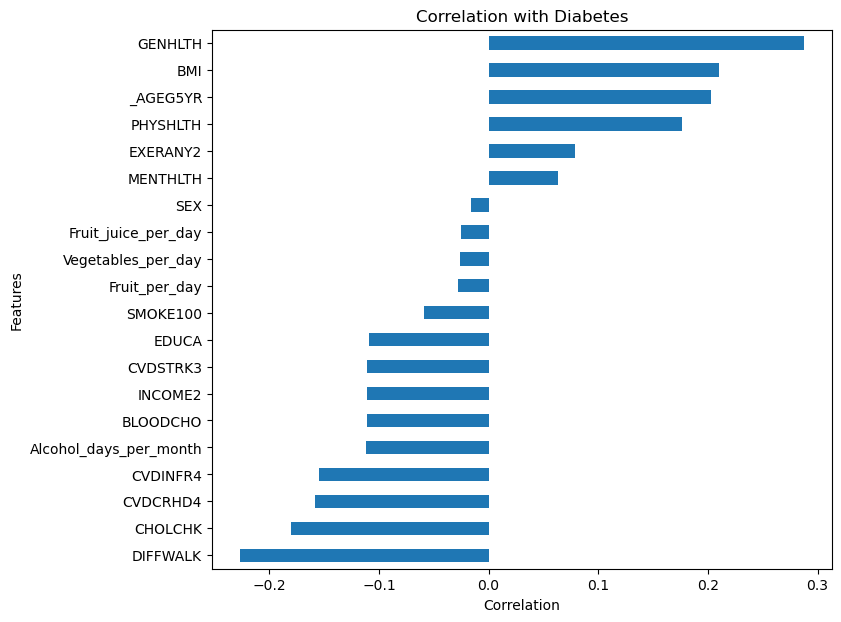

In [28]:
# Visualize correlation with diabetes

correlation_with_diabetes.drop("Diabetes_binary").sort_values().plot(kind="barh", figsize=(8, 7))

plt.title("Correlation with Diabetes")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

In [29]:
# Create clearer binary versions for correlation interpretation
# 1 = condition/risk present, 0 = condition/risk absent

df_corr = df.copy()

yes_no_columns = [
    "BLOODCHO",
    "CVDINFR4",
    "CVDCRHD4",
    "CVDSTRK3",
    "DIFFWALK",
    "SMOKE100"
]

for col in yes_no_columns:
    df_corr[col + "_binary"] = df_corr[col].map({
        1: 1,
        2: 0
    })

# For EXERANY2:
# 1 = physical activity, 2 = no physical activity, 3 = unknown
# Create a clearer variable: Physically_inactive
df_corr["Physically_inactive"] = df_corr["EXERANY2"].map({
    1: 0,
    2: 1,
    3: np.nan
})

# Calculate correlation using clearer variables
correlation_columns = [
    "Diabetes_binary",
    "BMI",
    "_AGEG5YR",
    "GENHLTH",
    "PHYSHLTH",
    "MENTHLTH",
    "Alcohol_days_per_month",
    "Fruit_juice_per_day",
    "Fruit_per_day",
    "Vegetables_per_day",
    "BLOODCHO_binary",
    "CVDINFR4_binary",
    "CVDCRHD4_binary",
    "CVDSTRK3_binary",
    "DIFFWALK_binary",
    "SMOKE100_binary",
    "Physically_inactive"
]

correlation_with_diabetes_clean = (
    df_corr[correlation_columns]
    .corr(numeric_only=True)["Diabetes_binary"]
    .sort_values(ascending=False)
)

correlation_with_diabetes_clean

Diabetes_binary           1.000000
GENHLTH                   0.287412
DIFFWALK_binary           0.226696
BMI                       0.210296
_AGEG5YR                  0.202817
PHYSHLTH                  0.176495
CVDCRHD4_binary           0.158101
CVDINFR4_binary           0.154389
Physically_inactive       0.113666
BLOODCHO_binary           0.110990
CVDSTRK3_binary           0.110812
MENTHLTH                  0.063422
SMOKE100_binary           0.058983
Fruit_juice_per_day      -0.025163
Vegetables_per_day       -0.026159
Fruit_per_day            -0.027920
Alcohol_days_per_month   -0.112156
Name: Diabetes_binary, dtype: float64

In [31]:
# After recoding yes/no variables into clearer binary indicators, the correlation results became easier to interpret. General health, difficulty walking, BMI, age group, physically unhealthy days, cardiovascular conditions, physical inactivity, and stroke history show positive associations with diabetes status. Food-consumption variables show weak negative correlations, suggesting that their direct linear relationship with diabetes is limited in this dataset. These correlations describe associations only and do not imply causation.


In [33]:
# Compare numerical features between diabetic and non-diabetic groups

df.groupby("Diabetes_binary")[numeric_features].mean().T

Diabetes_binary,0,1
BMI,27.445604,31.447764
PHYSHLTH,3.554841,8.081732
MENTHLTH,3.044927,4.453470
Alcohol_days_per_month,5.128813,2.440150
Fruit_juice_per_day,0.348347,0.298893
Fruit_per_day,1.020361,0.933974
Vegetables_per_day,0.810341,0.750827


<Figure size 700x400 with 0 Axes>

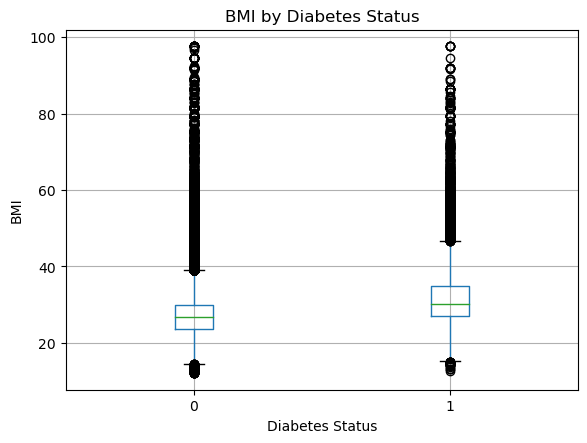

In [5]:
# Boxplot of BMI by diabetes status

plt.figure(figsize=(7, 4))
df.boxplot(column="BMI", by="Diabetes_binary")
plt.title("BMI by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.show()

In [7]:
# Calculate class imbalance ratio

diabetes_counts = df["Diabetes_binary"].value_counts().sort_index()

no_diabetes = diabetes_counts.loc[0]
diabetes = diabetes_counts.loc[1]

imbalance_ratio = round(no_diabetes / diabetes, 2)

print("No diabetes cases:", no_diabetes)
print("Diabetes cases:", diabetes)
print("Imbalance ratio:", imbalance_ratio, ": 1")

No diabetes cases: 329471
Diabetes cases: 49699
Imbalance ratio: 6.63 : 1


In [8]:
# Summary of key EDA findings

print("EDA Summary")
print("-----------")
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"No diabetes cases: {no_diabetes}")
print(f"Diabetes cases: {diabetes}")
print(f"Class imbalance ratio: {imbalance_ratio}:1")
print("BMI, age group, general health, physical activity, income, heart disease, and stroke should be examined carefully before modeling.")

EDA Summary
-----------
Dataset shape: 379170 rows and 21 columns
No diabetes cases: 329471
Diabetes cases: 49699
Class imbalance ratio: 6.63:1
BMI, age group, general health, physical activity, income, heart disease, and stroke should be examined carefully before modeling.


In [ ]:
# Save EDA-ready dataset with BMI category

df.to_csv(
    r"D:\document\AFTER_GRADUATION\DATAANALYSE\MINE\PROJECT4HEALTHCARE\data\cleaned\diabetes_eda_ready.csv",
    index=False
)

print("EDA-ready dataset saved successfully!")

In [9]:
#The target variable is imbalanced. There are approximately 6.63 non-diabetic respondents for every diabetic respondent. This imbalance should be considered during machine learning, because accuracy alone may overestimate model performance. Evaluation should include recall, precision, F1-score, ROC-AUC, PR-AUC, and confusion matrix.

In [10]:
# Check extreme values in food frequency variables

food_features = [
    "Fruit_juice_per_day",
    "Fruit_per_day",
    "Vegetables_per_day"
]

for col in food_features:
    print("\nColumn:", col)
    print("Values greater than 10 per day:", (df[col] > 10).sum())
    print("Percentage greater than 10 per day:", round((df[col] > 10).mean() * 100, 3))
    print("Maximum value:", df[col].max())


Column: Fruit_juice_per_day
Values greater than 10 per day: 39
Percentage greater than 10 per day: 0.01
Maximum value: 99.0

Column: Fruit_per_day
Values greater than 10 per day: 72
Percentage greater than 10 per day: 0.019
Maximum value: 99.0

Column: Vegetables_per_day
Values greater than 10 per day: 36
Percentage greater than 10 per day: 0.009
Maximum value: 99.0


In [11]:
# Cap extreme food-frequency values at 10 times per day

for col in food_features:
    df[col] = df[col].clip(upper=10)

df[food_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Fruit_juice_per_day,379170.0,0.340280,0.574604,0.0,0.000000,0.100000,0.428571,10.0
Fruit_per_day,379170.0,1.004913,0.893773,0.0,0.428571,1.000000,1.000000,10.0
Vegetables_per_day,379170.0,0.800262,0.633772,0.0,0.428571,0.714286,1.000000,10.0


In [12]:
# Save EDA-ready dataset with BMI category and capped food-frequency values

df.to_csv(
    r"D:\document\AFTER_GRADUATION\DATAANALYSE\MINE\PROJECT4HEALTHCARE\data\cleaned\diabetes_eda_ready.csv",
    index=False
)

print("EDA-ready dataset saved successfully!")

EDA-ready dataset saved successfully!
